In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv("vehical.csv")

In [46]:
df.head()

,Name,Year,Selling_price,Km_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [47]:
df.shape

(4340, 8)

In [48]:
df.columns

Index(['Name', 'Year', 'Selling_price', 'Km_Driven', 'Fuel', 'Seller_Type',
       'Transmission', 'Owner'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Name           4340 non-null   str  
 1   Year           4340 non-null   int64
 2   Selling_price  4340 non-null   int64
 3   Km_Driven      4340 non-null   int64
 4   Fuel           4340 non-null   str  
 5   Seller_Type    4340 non-null   str  
 6   Transmission   4340 non-null   str  
 7   Owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [50]:
df.isnull().sum()

Name             0
Year             0
Selling_price    0
Km_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(763)

In [52]:
df = df.drop_duplicates()

In [53]:
df.shape

(3577, 8)

In [54]:
df.dtypes

Name               str
Year             int64
Selling_price    int64
Km_Driven        int64
Fuel               str
Seller_Type        str
Transmission       str
Owner              str
dtype: object

In [55]:
df.describe()

,Year,Selling_price,Km_Driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [57]:
df["Selling_price"].describe()

count    3.577000e+03
mean     4.739125e+05
std      5.093018e+05
min      2.000000e+04
25%      2.000000e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: Selling_price, dtype: float64

In [58]:
df["Km_Driven"].describe()

count      3577.000000
mean      69250.545709
std       47579.940016
min           1.000000
25%       36000.000000
50%       60000.000000
75%       90000.000000
max      806599.000000
Name: Km_Driven, dtype: float64

In [59]:
df["brand"] = df["Name"].str.split().str[0]

In [40]:
df["brand"].head()

0     Maruti
1     Maruti
2    Hyundai
3     Datsun
4      Honda
Name: brand, dtype: object

In [60]:
df["vehicle_age"] = 2026 - df["Year"]

In [61]:
df["vehicle_age"].head()

0    19
1    19
2    14
3     9
4    12
Name: vehicle_age, dtype: int64

In [66]:
df["selling_price_lakh"] = df["Selling_price"] / 100000
df["selling_price_lakh"].head()

0    0.60
1    1.35
2    6.00
3    2.50
4    4.50
Name: selling_price_lakh, dtype: float64

In [69]:
df["Fuel"].value_counts()

Fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

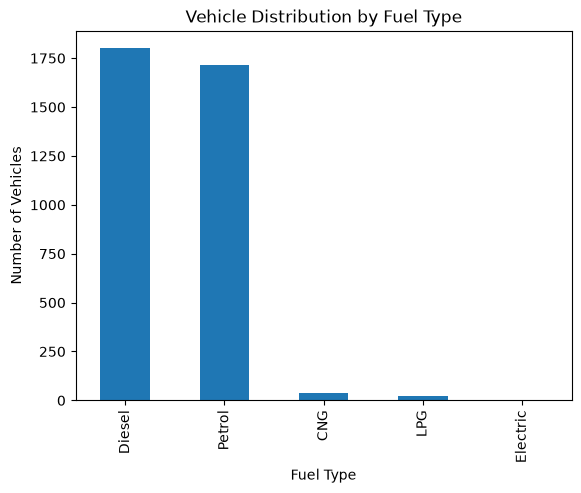

In [89]:
df["Fuel"].value_counts().plot(kind="bar")

plt.title("Vehicle Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Vehicles")
plt.show()

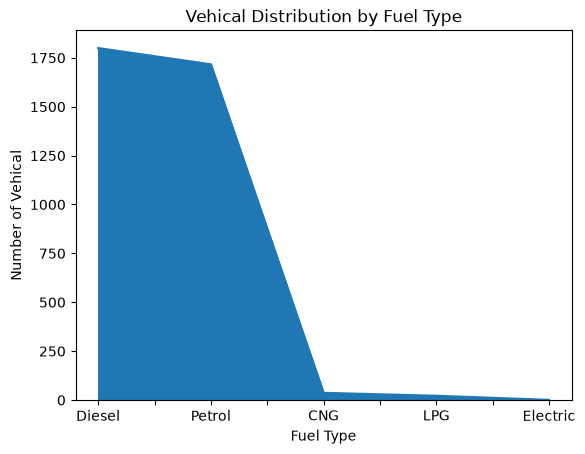

In [90]:
df["Fuel"].value_counts().plot(kind="area")
plt.title("Vehical Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Vehical")
plt.show()

In [92]:
df["Transmission"].value_counts()

Transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

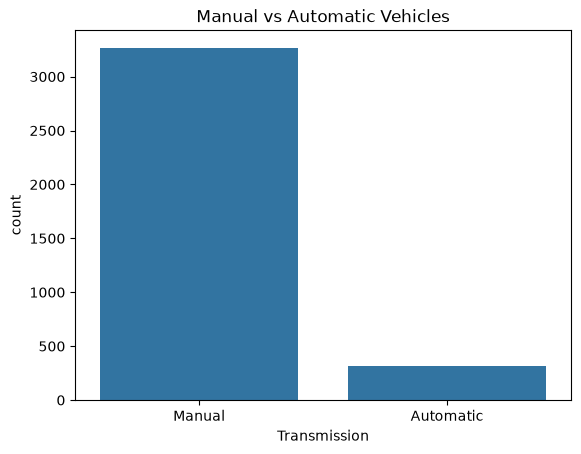

In [107]:
sns.countplot(data=df, x="Transmission")

plt.title("Manual vs Automatic Vehicles")
plt.show()

In [98]:
df["Owner"].value_counts()

Owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64

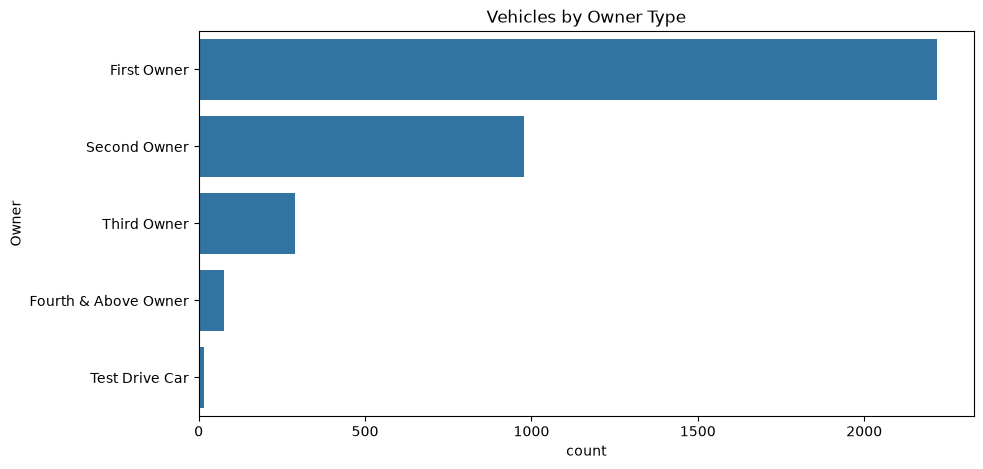

In [100]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Owner",
    order=df["Owner"].value_counts().index
)

plt.title("Vehicles by Owner Type")
plt.show()

In [110]:
df["Seller_Type"].value_counts()

Seller_Type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64

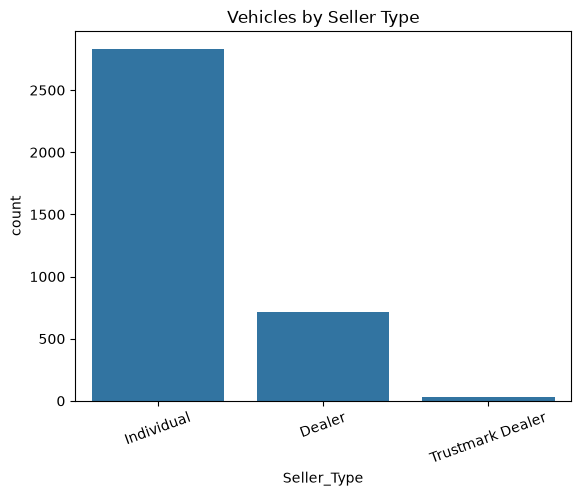

In [111]:
sns.countplot(data=df, x="Seller_Type")

plt.title("Vehicles by Seller Type")
plt.xticks(rotation=20)
plt.show()

In [113]:
df["brand"].value_counts().head(10)

brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64

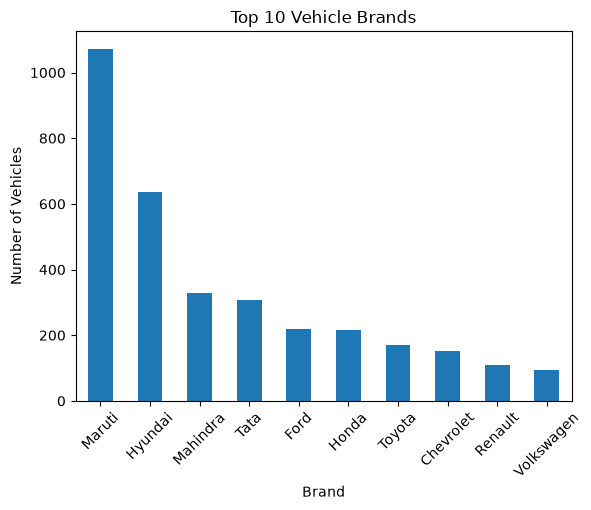

In [117]:
top_brands = df["brand"].value_counts().head(10)

top_brands.plot(kind="bar")

plt.title("Top 10 Vehicle Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

In [118]:
brand_price = (
    df.groupby("brand")["selling_price_lakh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

brand_price

brand
Land             36.098000
Volvo            25.562500
Mercedes-Benz    22.992381
BMW              22.428000
Audi             21.854516
Jaguar           20.729998
MG               18.425000
Jeep             15.300000
Isuzu            15.000000
Kia              13.000000
Name: selling_price_lakh, dtype: float64

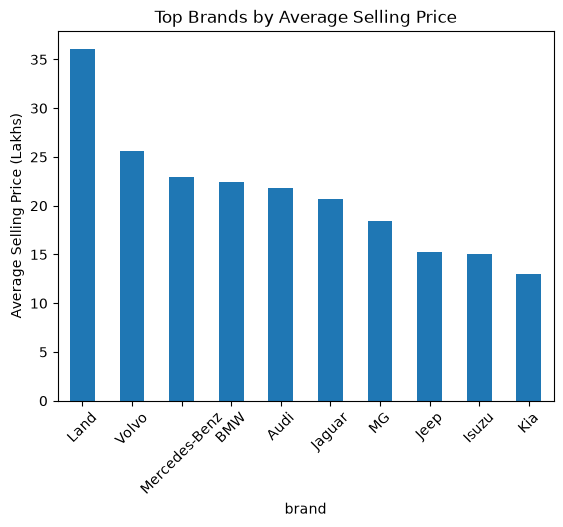

In [119]:
brand_price.plot(kind="bar")

plt.title("Top Brands by Average Selling Price")
plt.ylabel("Average Selling Price (Lakhs)")
plt.xticks(rotation=45)
plt.show()

In [121]:
fuel_price = (
    df.groupby("Fuel")["selling_price_lakh"]
    .mean()
    .sort_values(ascending=False)
)

fuel_price

Fuel
Diesel      6.140011
Petrol      3.353443
Electric    3.100000
CNG         2.731621
LPG         1.718181
Name: selling_price_lakh, dtype: float64

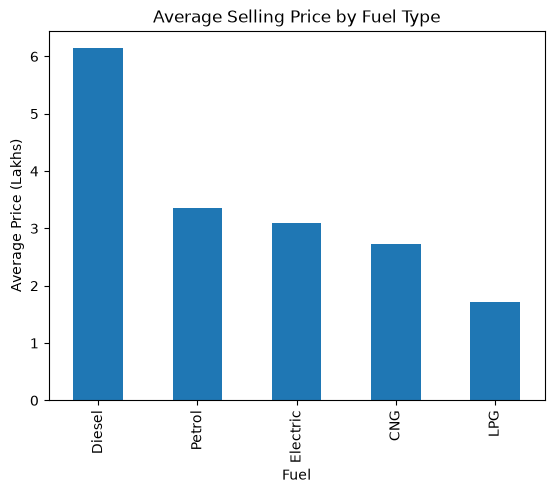

In [122]:
fuel_price.plot(kind="bar")

plt.title("Average Selling Price by Fuel Type")
plt.ylabel("Average Price (Lakhs)")
plt.show()

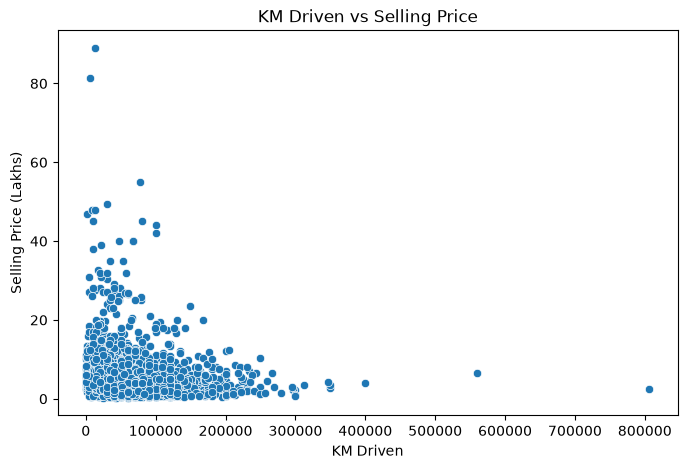

In [123]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Km_Driven",
    y="selling_price_lakh"
)

plt.title("KM Driven vs Selling Price")
plt.xlabel("KM Driven")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

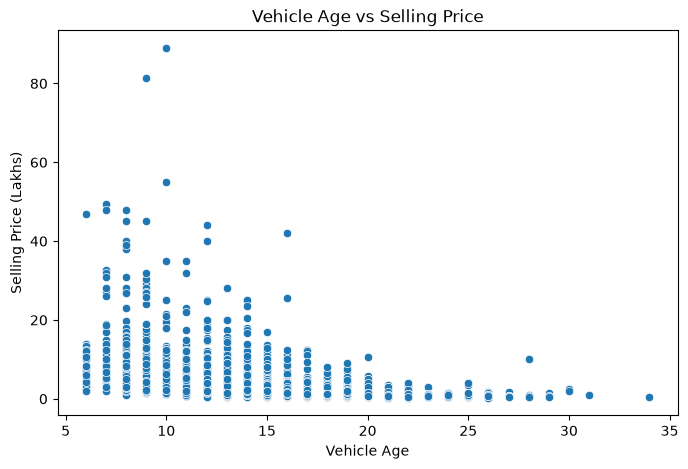

In [134]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price_lakh"
)

plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

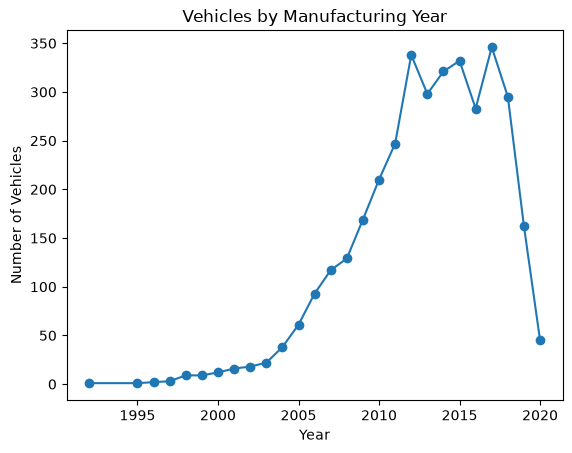

In [133]:
year_count = df["Year"].value_counts().sort_index()

year_count.plot(kind="line", marker="o")

plt.title("Vehicles by Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")
plt.show()

In [136]:
df[[
    "Year",
    "Selling_price",
    "Km_Driven",
    "vehicle_age"
]].corr()

,Year,Selling_price,Km_Driven,vehicle_age
Year,1.00000,0.424260,-0.417490,-1.00000
Selling_price,0.42426,1.000000,-0.187359,-0.42426
Km_Driven,-0.41749,-0.187359,1.000000,0.41749
vehicle_age,-1.00000,-0.424260,0.417490,1.00000


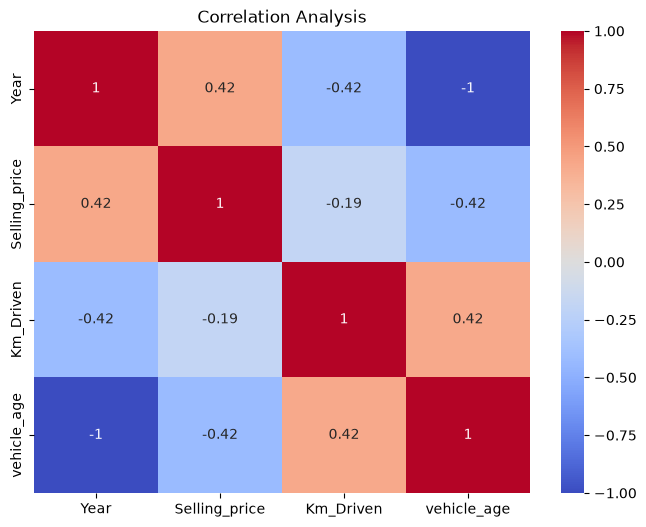

In [139]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "Year",
        "Selling_price",
        "Km_Driven",
        "vehicle_age"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Analysis")
plt.show()

In [140]:
df.to_csv("vehicle_cleaned.csv", index=False)